# EDA Figures for IELTS AES Slides

Notebook này tạo các hình EDA/Pattern Recognition cần chèn vào slide Beamer.

**Mục tiêu:**  
- Dùng đúng kiểu chạy local như notebook EDA cũ: đọc `concat_dataset.csv` từ thư mục local.
- Xuất hình `.png` vào các folder khớp với slide:
  - `figures/eda/`
  - `figures/pr/`
  - `figures/results/`

Bạn chỉ cần sửa `PROJECT_DIR` / `DATA_PATH` cho đúng máy của bạn rồi chạy all.

In [1]:
# =========================
# 0. Imports and global style
# =========================

import os
import re
import json
import math
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 200)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Matplotlib style: clean, readable for slides
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["figure.dpi"] = 120

In [2]:
# =========================
# 1. Local dataset config
# =========================
# Sửa đúng đường dẫn local của bạn nếu khác.
# Notebook gốc của bạn dùng:
# C:\Users\PC\IELTS-Writing-Evals\dataset\full_concat_ds\concat_dataset.csv

PROJECT_DIR = Path(r"C:\Users\PC\IELTS-Writing-Evals")
DATA_PATH = PROJECT_DIR / "dataset" / "full_concat_ds" / "concat_dataset.csv"

# Folder xuất hình cho slide
OUTPUT_ROOT = PROJECT_DIR / "slide_figures"
EDA_DIR = OUTPUT_ROOT / "eda"
PR_DIR = OUTPUT_ROOT / "pr"
RESULTS_DIR = OUTPUT_ROOT / "results"

for d in [EDA_DIR, PR_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("Exists:", DATA_PATH.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy DATA_PATH: {DATA_PATH}\n"
        "Hãy sửa PROJECT_DIR hoặc DATA_PATH cho đúng máy local của bạn."
    )

DATA_PATH: C:\Users\PC\IELTS-Writing-Evals\dataset\full_concat_ds\concat_dataset.csv
Exists: True
OUTPUT_ROOT: C:\Users\PC\IELTS-Writing-Evals\slide_figures


In [3]:
# =========================
# 2. Load CSV safely
# =========================

def read_csv_safely(path: Path) -> pd.DataFrame:
    encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252"]
    last_err = None
    for enc in encodings:
        try:
            print(f"Trying encoding: {enc}")
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Cannot read {path}: {last_err}")

df_raw = read_csv_safely(DATA_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head())
display(pd.DataFrame({"column": df_raw.columns, "dtype": [str(df_raw[c].dtype) for c in df_raw.columns]}))

Trying encoding: utf-8
Raw shape: (9682, 17)


,prompt,essay,evaluation,essay_len,TR,CC,LR,GRA,n_found,parse_quality,overall_raw,band,prompt_relevance,lexical_diversity,readability_score,target_text,source
0,"Some people think parents should read or tell stories to children. Others think parents needn’t do that as children can read books or watch TV, movies by themselves. Discuss both views and give yo...","There are divergent views regarding the role of parents in storytelling or reading to children, with some suggesting that it is important for parents to do so, while others argue that it is necess...",Suggested Band Score: 6.5\r\n\r\n Task Achievement:\r\n- The essay adequately addresses the task by discussing both views on the role of parents in storytelling or reading to children and providin...,343,7.0,7.0,6.5,6.5,4,good,6.750,7.0,0.733613,0.495677,29.663589,"Analysis: This essay has a lexical diversity of 0.50, a readability score of 29.7, and its relevance to the prompt is 0.73. Detailed Evaluation: Suggested Band Score: 6.5\r\n\r\n Task Achievement:...",hf
1,some countries more and more people are becoming interested in finding out bout the history of the house or building they live in. What are the reasons for this? How can people research this?,"In Several nations, increasingly people are becoming interested to know about the houses or buildings they live in. There is a reason behind that, also this essay is going to be about effective wa...",Task Achievement:\r\n- Suggested Band Score: 5\r\n- The candidate has adequately addressed the task by providing reasons for the growing interest in house history and discussing methods for resear...,268,5.0,5.5,5.0,5.0,4,good,5.125,5.0,0.559742,0.501845,61.370398,"Analysis: This essay has a lexical diversity of 0.50, a readability score of 61.4, and its relevance to the prompt is 0.56. Detailed Evaluation: Task Achievement:\r\n- Suggested Band Score: 5\r\n-...",hf
2,"Nowadays families move to different countries for work. Some people think it has a negative effect on children, while others disagree. Discuss both views and give your own opinion.","Advances in technology and transportation have made globalization much easier, accordingly multinational corporations have become considerably more widespread all over the word and as a result, it...",Task Achievement:\r\nThe candidate has addressed the task by discussing both views on the potential effects of families moving to different countries for work on children and providing their own o...,447,6.0,6.0,5.0,5.0,4,good,5.500,5.5,0.549019,0.487696,3.291141,"Analysis: This essay has a lexical diversity of 0.49, a readability score of 3.3, and its relevance to the prompt is 0.55. Detailed Evaluation: Task Achievement:\r\nThe candidate has addressed the...",hf
3,"Some people think that technology makes life complex, so we should make our life simpler without using the technology. To what extent do you agree or disagree?","Nowadays, it is often suggested that people's lifestyle is complicated by the advent of technological advances. Some people argue that people should reduce the usage of electronic products because...","Task Achievement:\r\n- The candidate has adequately addressed the task by presenting a clear stance and supporting it with relevant ideas.\r\n- The essay covers all aspects of the task, discussing...",325,6.5,6.0,6.0,6.0,4,good,6.125,6.0,0.422087,0.588415,34.645795,"Analysis: This essay has a lexical diversity of 0.59, a readability score of 34.6, and its relevance to the prompt is 0.42. Detailed Evaluation: Task Achievement:\r\n- The candidate has adequately...",hf
4,"Some people think news has no connection to people’s lives, so it is a waste of time to read news in the newspaper and watch news programs in television. To what extent do you agree or disagree?","Nowadays, the newspaper has a huge connection to human life. You can easily see people reading the news everywhere. Although there are many advantages that the news brings to our daily lives, ther...","Tas

,column,dtype
0,prompt,object
1,essay,object
2,evaluation,object
3,essay_len,int64
4,TR,float64
5,CC,float64
6,LR,float64
7,GRA,float64
8,n_found,int64
9,parse_quality,object


In [4]:
# =========================
# 3. Normalize column names
# =========================

COLUMN_ALIASES = {
    "prompt": [
        "prompt", "question", "task", "topic", "essay_prompt",
        "Prompt", "Question", "Task", "Topic"
    ],
    "essay": [
        "essay", "response", "answer", "text", "content",
        "Essay", "Response", "Answer", "Text", "Content"
    ],
    "TR": [
        "TR", "tr", "Task Response", "task_response", "task response",
        "TaskResponse", "task_achievement", "TA", "task_achievement_score"
    ],
    "CC": [
        "CC", "cc", "Coherence and Cohesion", "coherence_cohesion",
        "coherence cohesion", "Coherence", "coherence", "cohesion"
    ],
    "LR": [
        "LR", "lr", "Lexical Resource", "lexical_resource",
        "lexical resource", "Vocabulary", "vocabulary"
    ],
    "GRA": [
        "GRA", "gra", "Grammar", "grammar",
        "Grammatical Range and Accuracy", "grammatical_range_accuracy",
        "grammatical range and accuracy"
    ],
    "band": [
        "band", "score", "overall", "overall_band", "Overall", "Band",
        "overall_score", "final_score"
    ],
    "split": ["split", "Split", "set", "dataset_split"],
    "source_file": ["source_file", "source", "dataset", "Source", "file"]
}

def find_first_existing(columns, aliases):
    columns_set = set(columns)
    for a in aliases:
        if a in columns_set:
            return a
    # fuzzy normalized match
    norm_map = {re.sub(r"[^a-z0-9]+", "", c.lower()): c for c in columns}
    for a in aliases:
        key = re.sub(r"[^a-z0-9]+", "", a.lower())
        if key in norm_map:
            return norm_map[key]
    return None

rename_map = {}
for canonical, aliases in COLUMN_ALIASES.items():
    found = find_first_existing(df_raw.columns, aliases)
    if found is not None:
        rename_map[found] = canonical

df = df_raw.rename(columns=rename_map).copy()

required = ["prompt", "essay", "TR", "CC", "LR", "GRA"]
missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise ValueError(f"Thiếu cột bắt buộc sau khi normalize: {missing_required}\nColumns hiện có: {list(df.columns)}")

for c in ["TR", "CC", "LR", "GRA", "band"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "band" not in df.columns or df["band"].isna().all():
    df["band"] = df[["TR", "CC", "LR", "GRA"]].mean(axis=1)

# Normalize split labels if available
if "split" in df.columns:
    df["split"] = df["split"].astype(str).str.lower().str.strip()
    df["split"] = df["split"].replace({
        "valid": "validation",
        "val": "validation",
        "dev": "validation",
        "test_set": "test",
        "train_set": "train"
    })

if "source_file" not in df.columns:
    df["source_file"] = "combined_dataset"

# Basic clean text
df["prompt"] = df["prompt"].fillna("").astype(str)
df["essay"] = df["essay"].fillna("").astype(str)

print("Normalized shape:", df.shape)
print("Columns:", list(df.columns))
display(df[["prompt", "essay", "TR", "CC", "LR", "GRA", "band"] + ([ "split" ] if "split" in df.columns else []) + ["source_file"]].head())

Normalized shape: (9682, 17)
Columns: ['prompt', 'essay', 'evaluation', 'essay_len', 'TR', 'CC', 'LR', 'GRA', 'n_found', 'parse_quality', 'overall_raw', 'band', 'prompt_relevance', 'lexical_diversity', 'readability_score', 'target_text', 'source_file']


,prompt,essay,TR,CC,LR,GRA,band,source_file
0,"Some people think parents should read or tell stories to children. Others think parents needn’t do that as children can read books or watch TV, movies by themselves. Discuss both views and give yo...","There are divergent views regarding the role of parents in storytelling or reading to children, with some suggesting that it is important for parents to do so, while others argue that it is necess...",7.0,7.0,6.5,6.5,7.0,hf
1,some countries more and more people are becoming interested in finding out bout the history of the house or building they live in. What are the reasons for this? How can people research this?,"In Several nations, increasingly people are becoming interested to know about the houses or buildings they live in. There is a reason behind that, also this essay is going to be about effective wa...",5.0,5.5,5.0,5.0,5.0,hf
2,"Nowadays families move to different countries for work. Some people think it has a negative effect on children, while others disagree. Discuss both views and give your own opinion.","Advances in technology and transportation have made globalization much easier, accordingly multinational corporations have become considerably more widespread all over the word and as a result, it...",6.0,6.0,5.0,5.0,5.5,hf
3,"Some people think that technology makes life complex, so we should make our life simpler without using the technology. To what extent do you agree or disagree?","Nowadays, it is often suggested that people's lifestyle is complicated by the advent of technological advances. Some people argue that people should reduce the usage of electronic products because...",6.5,6.0,6.0,6.0,6.0,hf
4,"Some people think news has no connection to people’s lives, so it is a waste of time to read news in the newspaper and watch news programs in television. To what extent do you agree or disagree?","Nowadays, the newspaper has a huge connection to human life. You can easily see people reading the news everywhere. Although there are many advantages that the news brings to our daily lives, ther...",7.5,8.0,7.0,6.5,7.5,hf


In [5]:
# =========================
# 4. Create stratified split if missing
# =========================
# Nếu dataset đã có cột split thì giữ nguyên.
# Nếu chưa có, tạo train/validation/test = 80/10/10 theo band.

def to_band_stratify_label(s):
    # Round to half band for stable stratification
    return (np.round(pd.to_numeric(s, errors="coerce") * 2) / 2).astype(str)

if "split" not in df.columns or df["split"].isna().all() or (df["split"].astype(str).str.lower() == "nan").all():
    print("No valid split column found. Creating stratified 80/10/10 split by band...")
    try:
        from sklearn.model_selection import train_test_split

        strat = to_band_stratify_label(df["band"])
        train_idx, temp_idx = train_test_split(
            df.index,
            test_size=0.20,
            random_state=RANDOM_SEED,
            stratify=strat
        )
        temp_strat = strat.loc[temp_idx]
        val_idx, test_idx = train_test_split(
            temp_idx,
            test_size=0.50,
            random_state=RANDOM_SEED,
            stratify=temp_strat
        )

        df["split"] = "train"
        df.loc[val_idx, "split"] = "validation"
        df.loc[test_idx, "split"] = "test"

    except Exception as e:
        print("Stratified split failed, fallback to random split:", e)
        rng = np.random.default_rng(RANDOM_SEED)
        perm = rng.permutation(df.index)
        n = len(df)
        n_train = int(n * 0.80)
        n_val = int(n * 0.10)
        df["split"] = "test"
        df.loc[perm[:n_train], "split"] = "train"
        df.loc[perm[n_train:n_train+n_val], "split"] = "validation"

display(df["split"].value_counts().to_frame("count"))
display((df["split"].value_counts(normalize=True) * 100).round(2).to_frame("pct"))

No valid split column found. Creating stratified 80/10/10 split by band...
Stratified split failed, fallback to random split: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.


,count
split,
train,7745
test,969
validation,968


,pct
split,
train,79.99
test,10.01
validation,10.00


In [6]:
# =========================
# 5. Lightweight text + discourse feature extraction
# =========================

STOPWORDS = {
    "a","an","the","and","or","but","if","while","although","because","as","of","at","by","for","with","about",
    "against","between","into","through","during","before","after","above","below","to","from","up","down",
    "in","out","on","off","over","under","again","further","then","once","here","there","when","where","why",
    "how","all","any","both","each","few","more","most","other","some","such","no","nor","not","only","own",
    "same","so","than","too","very","can","will","just","should","now","i","me","my","we","our","you","your",
    "he","him","his","she","her","it","its","they","them","their","this","that","these","those","is","are",
    "was","were","be","been","being","have","has","had","do","does","did"
}

DISCOURSE_MARKERS = {
    "contrast": ["however", "nevertheless", "nonetheless", "on the other hand", "in contrast", "whereas", "while"],
    "addition": ["moreover", "furthermore", "in addition", "also", "besides", "additionally"],
    "cause": ["because", "since", "as a result", "therefore", "thus", "consequently", "hence"],
    "example": ["for example", "for instance", "such as", "namely"],
    "conclusion": ["in conclusion", "to conclude", "overall", "in summary", "to sum up"],
    "sequence": ["firstly", "secondly", "thirdly", "finally", "next"]
}

def simple_word_tokenize(text):
    return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", str(text).lower())

def simple_sentence_tokenize(text):
    # Simple split that is enough for EDA plots
    sents = re.split(r"[.!?]+", str(text))
    return [s.strip() for s in sents if s.strip()]

def ngram_diversity(tokens, n):
    if len(tokens) < n:
        return 0.0
    grams = list(zip(*[tokens[i:] for i in range(n)]))
    return len(set(grams)) / max(len(grams), 1)

def count_phrases(text_lower, phrases):
    count = 0
    for p in phrases:
        count += len(re.findall(r"\b" + re.escape(p) + r"\b", text_lower))
    return count

def extract_features(prompt, essay):
    prompt = str(prompt)
    essay = str(essay)
    essay_lower = essay.lower()

    tokens = simple_word_tokenize(essay)
    prompt_tokens = simple_word_tokenize(prompt)
    sents = simple_sentence_tokenize(essay)
    paragraphs = [p for p in re.split(r"\n\s*\n", essay) if p.strip()]

    word_count = len(tokens)
    unique_word_count = len(set(tokens))
    sentence_count = len(sents)
    paragraph_count = max(len(paragraphs), 1) if essay.strip() else 0

    sent_lens = [len(simple_word_tokenize(s)) for s in sents]
    avg_sentence_len = np.mean(sent_lens) if sent_lens else 0
    sentence_len_std = np.std(sent_lens) if sent_lens else 0

    words_no_stop = [w for w in tokens if w not in STOPWORDS]
    long_words = [w for w in tokens if len(w) >= 7]

    # Prompt overlap
    prompt_set = set(prompt_tokens)
    essay_set = set(tokens)
    prompt_overlap = len(prompt_set & essay_set) / max(len(prompt_set), 1)

    # Adjacent sentence lexical overlap
    overlaps = []
    sent_token_sets = [set(simple_word_tokenize(s)) for s in sents]
    for a, b in zip(sent_token_sets[:-1], sent_token_sets[1:]):
        overlaps.append(len(a & b) / max(len(a | b), 1))
    adjacent_sentence_overlap_mean = float(np.mean(overlaps)) if overlaps else 0.0

    # Discourse marker counts
    disc_counts = {}
    total_discourse = 0
    for group, phrases in DISCOURSE_MARKERS.items():
        c = count_phrases(essay_lower, phrases)
        disc_counts[f"{group}_marker_count"] = c
        total_discourse += c

    return {
        "word_count": word_count,
        "sentence_count": sentence_count,
        "paragraph_count": paragraph_count,
        "unique_word_count": unique_word_count,
        "avg_word_len": np.mean([len(w) for w in tokens]) if tokens else 0,
        "avg_sentence_len": avg_sentence_len,
        "sentence_len_std": sentence_len_std,
        "type_token_ratio": unique_word_count / max(word_count, 1),
        "content_word_ratio": len(words_no_stop) / max(word_count, 1),
        "long_word_ratio": len(long_words) / max(word_count, 1),
        "bigram_diversity": ngram_diversity(tokens, 2),
        "trigram_diversity": ngram_diversity(tokens, 3),
        "prompt_overlap": prompt_overlap,
        "adjacent_sentence_overlap_mean": adjacent_sentence_overlap_mean,
        "comma_per_sentence": essay.count(",") / max(sentence_count, 1),
        "semicolon_colon_per_sentence": (essay.count(";") + essay.count(":")) / max(sentence_count, 1),
        "discourse_marker_count": total_discourse,
        "discourse_per_100_words": total_discourse / max(word_count, 1) * 100,
        **disc_counts,
    }

feature_df = pd.DataFrame([extract_features(p, e) for p, e in zip(df["prompt"], df["essay"])])
df_eda = pd.concat([df.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)

# Band group for cleaner plots
bins = [-0.1, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
labels = ["0-3", "3.5-4", "4.5-5", "5.5-6", "6.5-7", "7.5-8", "8.5-9"]
df_eda["band_group"] = pd.cut(df_eda["band"], bins=bins, labels=labels, include_lowest=True)

print("df_eda shape:", df_eda.shape)
display(df_eda[["band", "band_group", "word_count", "sentence_count", "type_token_ratio", "discourse_marker_count"]].head())
df_eda.to_csv(OUTPUT_ROOT / "df_eda_with_features.csv", index=False)
print("Saved:", OUTPUT_ROOT / "df_eda_with_features.csv")

df_eda shape: (9682, 43)


,band,band_group,word_count,sentence_count,type_token_ratio,discourse_marker_count
0,7.0,6.5-7,347,11,0.495677,6
1,5.0,4.5-5,271,12,0.501845,7
2,5.5,5.5-6,447,7,0.487696,14
3,6.0,5.5-6,326,15,0.592025,9
4,7.5,7.5-8,311,15,0.530547,11


Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\df_eda_with_features.csv


In [7]:
# =========================
# 6. Plot helper functions
# =========================

def savefig(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    print("Saved:", path)
    plt.show()

def clean_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def add_bar_labels(ax, fmt="{:.0f}", rotation=0):
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h) and h > 0:
            ax.annotate(
                fmt.format(h),
                (p.get_x() + p.get_width() / 2, h),
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=rotation
            )

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\eda\dataset_overview_table.png


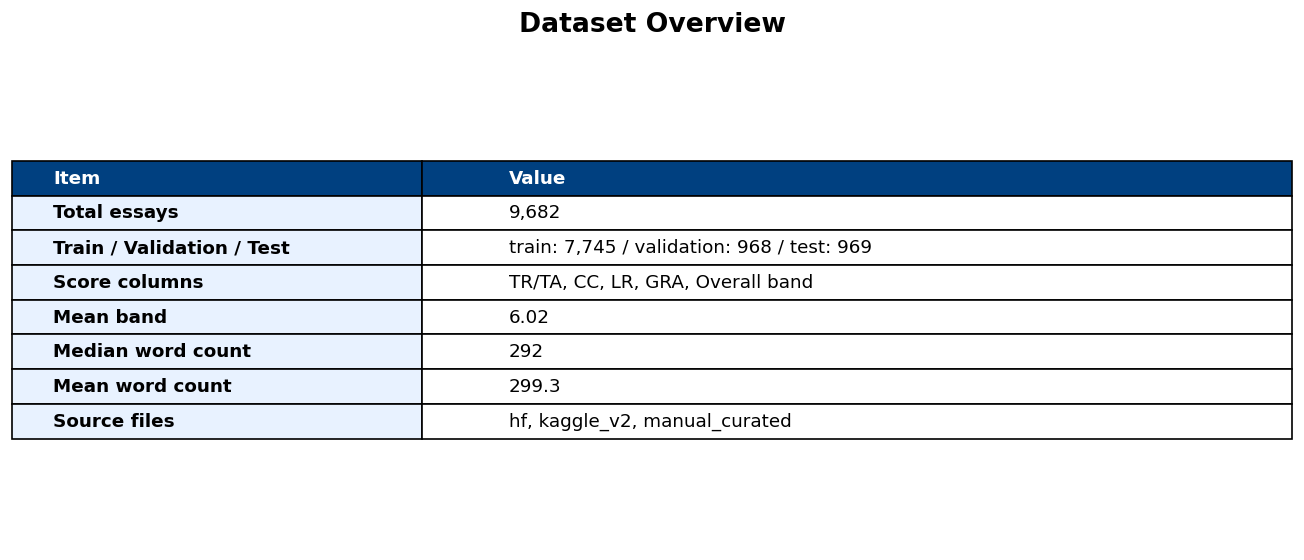

In [8]:
# =========================
# 7. Figure: dataset overview table
# Output: figures/eda/dataset_overview_table.png
# =========================

summary_rows = [
    ["Total essays", f"{len(df_eda):,}"],
    ["Train / Validation / Test", " / ".join([f"{s}: {n:,}" for s, n in df_eda['split'].value_counts().reindex(['train','validation','test']).dropna().items()])],
    ["Score columns", "TR/TA, CC, LR, GRA, Overall band"],
    ["Mean band", f"{df_eda['band'].mean():.2f}"],
    ["Median word count", f"{df_eda['word_count'].median():.0f}"],
    ["Mean word count", f"{df_eda['word_count'].mean():.1f}"],
    ["Source files", ", ".join(map(str, df_eda['source_file'].dropna().unique()[:4])) + (" ..." if df_eda['source_file'].nunique() > 4 else "")]
]

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.axis("off")
table = ax.table(
    cellText=summary_rows,
    colLabels=["Item", "Value"],
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.32, 0.68]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.55)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#004080")
    elif col == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#E8F2FF")
    else:
        cell.set_facecolor("#FFFFFF")

ax.set_title("Dataset Overview", fontsize=16, fontweight="bold", pad=12)
savefig(EDA_DIR / "dataset_overview_table.png")

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\eda\source_split_summary.png


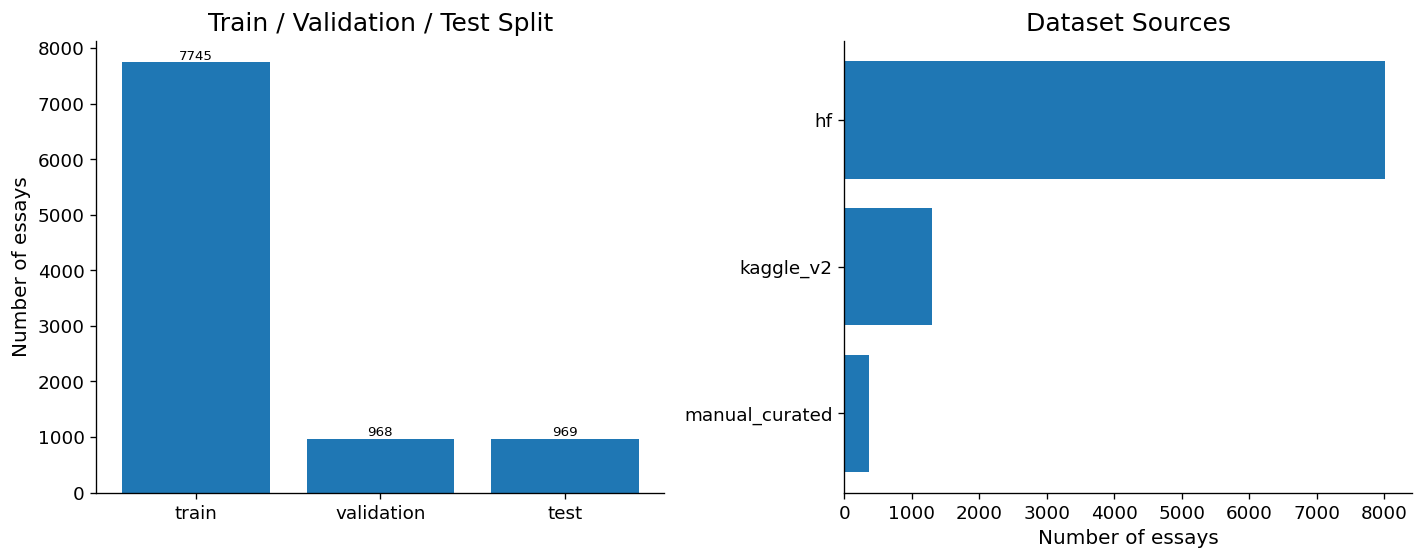

In [9]:
# =========================
# 8. Figure: source and split summary
# Output: figures/eda/source_split_summary.png
# =========================

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Split distribution
split_order = [s for s in ["train", "validation", "test"] if s in set(df_eda["split"])]
split_counts = df_eda["split"].value_counts().reindex(split_order)
axes[0].bar(split_counts.index, split_counts.values)
axes[0].set_title("Train / Validation / Test Split")
axes[0].set_ylabel("Number of essays")
add_bar_labels(axes[0])
clean_ax(axes[0])

# Source distribution
source_counts = df_eda["source_file"].astype(str).value_counts().head(8)
axes[1].barh(source_counts.index[::-1], source_counts.values[::-1])
axes[1].set_title("Dataset Sources")
axes[1].set_xlabel("Number of essays")
clean_ax(axes[1])

savefig(EDA_DIR / "source_split_summary.png")

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\eda\band_distribution.png


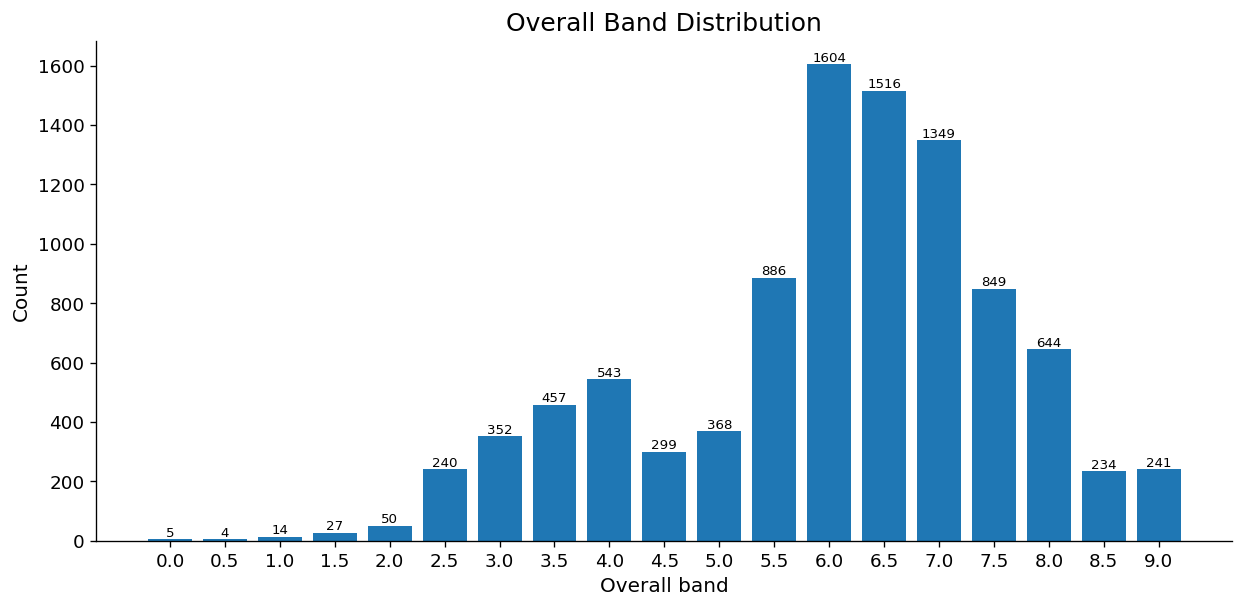

In [10]:
# =========================
# 9. Figure: band distribution
# Output: figures/eda/band_distribution.png
# =========================

band_counts = df_eda["band"].dropna().value_counts().sort_index()

plt.figure(figsize=(10.5, 5.2))
ax = plt.gca()
ax.bar([str(x) for x in band_counts.index], band_counts.values)
ax.set_title("Overall Band Distribution")
ax.set_xlabel("Overall band")
ax.set_ylabel("Count")
add_bar_labels(ax)
clean_ax(ax)
savefig(EDA_DIR / "band_distribution.png")

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\eda\band_by_split.png


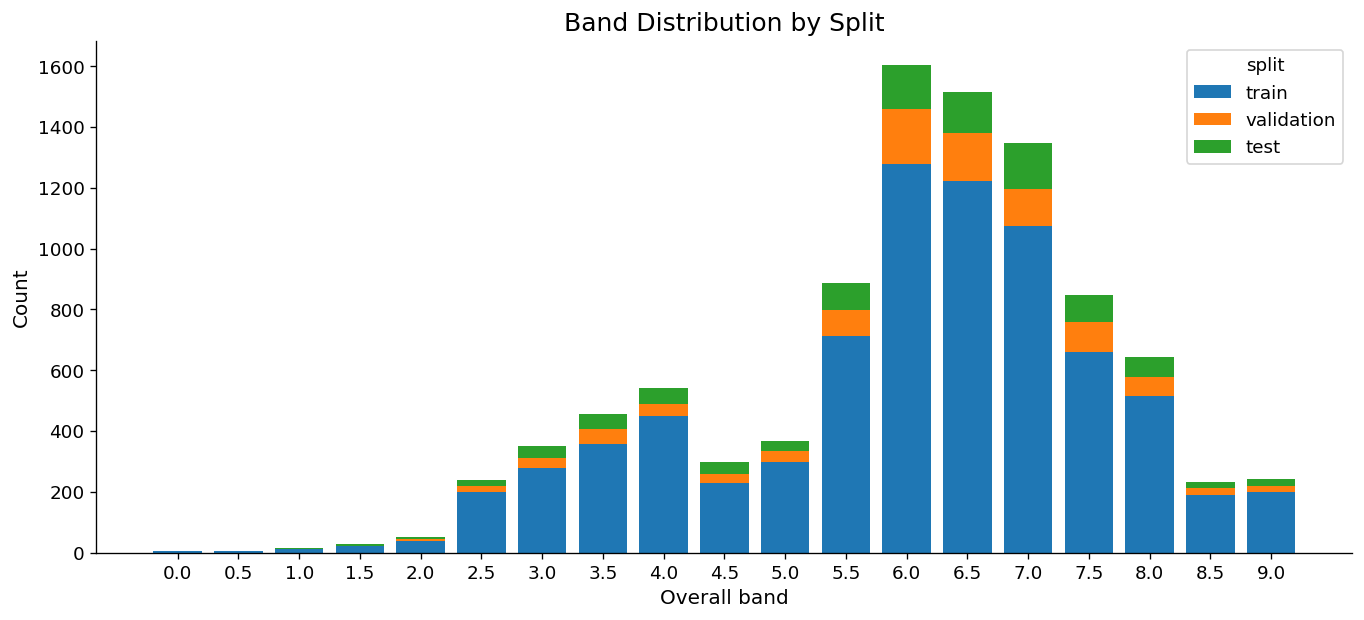

In [11]:
# =========================
# 10. Figure: stratified split check by band
# Output: figures/eda/band_by_split.png
# =========================

pivot = pd.crosstab(df_eda["band"], df_eda["split"])
split_order = [s for s in ["train", "validation", "test"] if s in pivot.columns]
pivot = pivot[split_order]

fig, ax = plt.subplots(figsize=(11.5, 5.3))
bottom = np.zeros(len(pivot))
x = np.arange(len(pivot.index))

for s in split_order:
    ax.bar(x, pivot[s].values, bottom=bottom, label=s)
    bottom += pivot[s].values

ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in pivot.index], rotation=0)
ax.set_title("Band Distribution by Split")
ax.set_xlabel("Overall band")
ax.set_ylabel("Count")
ax.legend(title="split")
clean_ax(ax)
savefig(EDA_DIR / "band_by_split.png")

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\eda\trait_correlation_heatmap.png


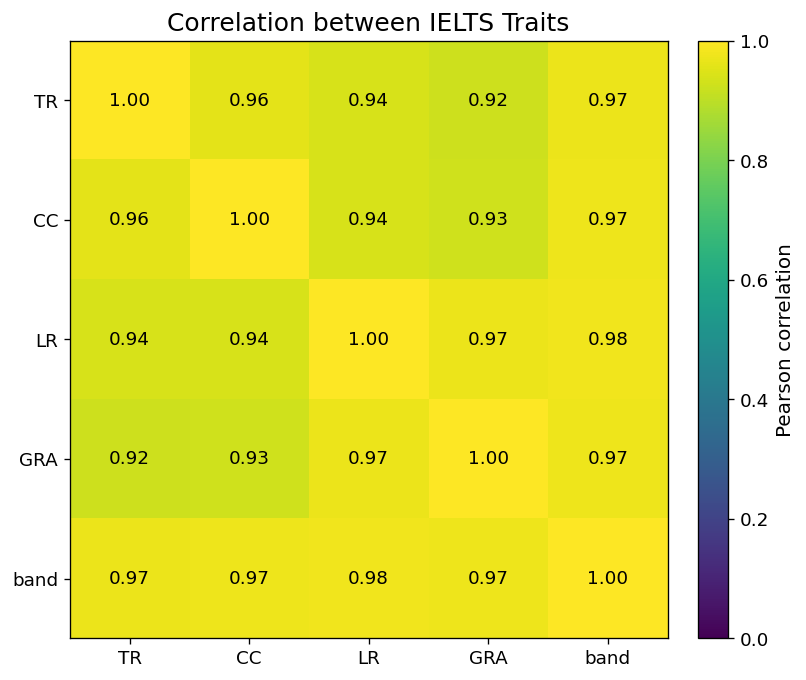

In [12]:
# =========================
# 11. Figure: trait correlation heatmap
# Output: figures/eda/trait_correlation_heatmap.png
# =========================

traits = ["TR", "CC", "LR", "GRA", "band"]
corr = df_eda[traits].corr()

fig, ax = plt.subplots(figsize=(7.2, 5.8))
im = ax.imshow(corr.values, vmin=0, vmax=1)

ax.set_xticks(np.arange(len(traits)))
ax.set_yticks(np.arange(len(traits)))
ax.set_xticklabels(traits)
ax.set_yticklabels(traits)

for i in range(len(traits)):
    for j in range(len(traits)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=11)

ax.set_title("Correlation between IELTS Traits")
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation")
savefig(EDA_DIR / "trait_correlation_heatmap.png")

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\eda\trait_distributions_grid.png


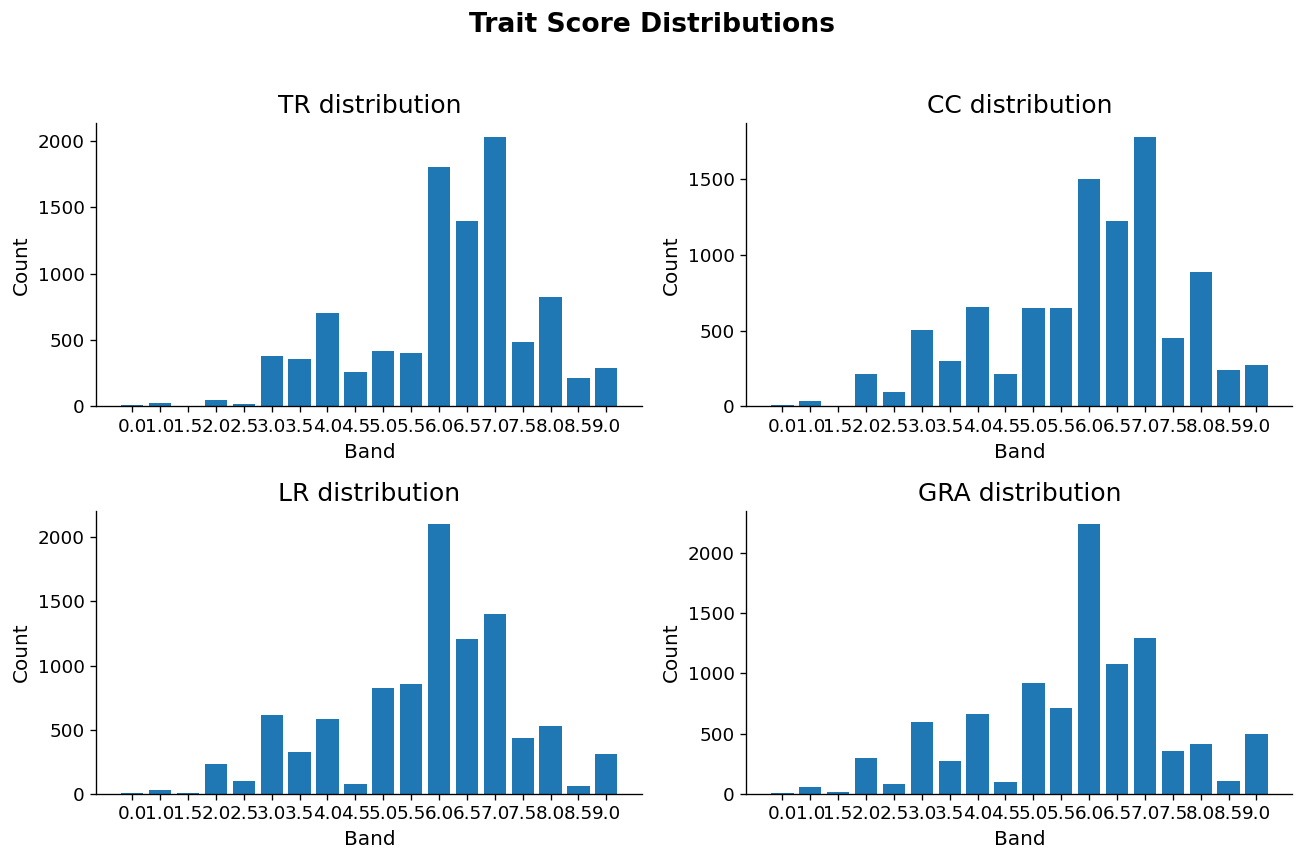

In [13]:
# =========================
# 12. Figure: distributions of 4 traits
# Output: figures/eda/trait_distributions_grid.png
# =========================

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()

for ax, trait in zip(axes, ["TR", "CC", "LR", "GRA"]):
    counts = df_eda[trait].dropna().value_counts().sort_index()
    ax.bar([str(x) for x in counts.index], counts.values)
    ax.set_title(f"{trait} distribution")
    ax.set_xlabel("Band")
    ax.set_ylabel("Count")
    clean_ax(ax)

plt.suptitle("Trait Score Distributions", fontsize=16, fontweight="bold", y=1.02)
savefig(EDA_DIR / "trait_distributions_grid.png")

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\eda\word_count_by_band.png


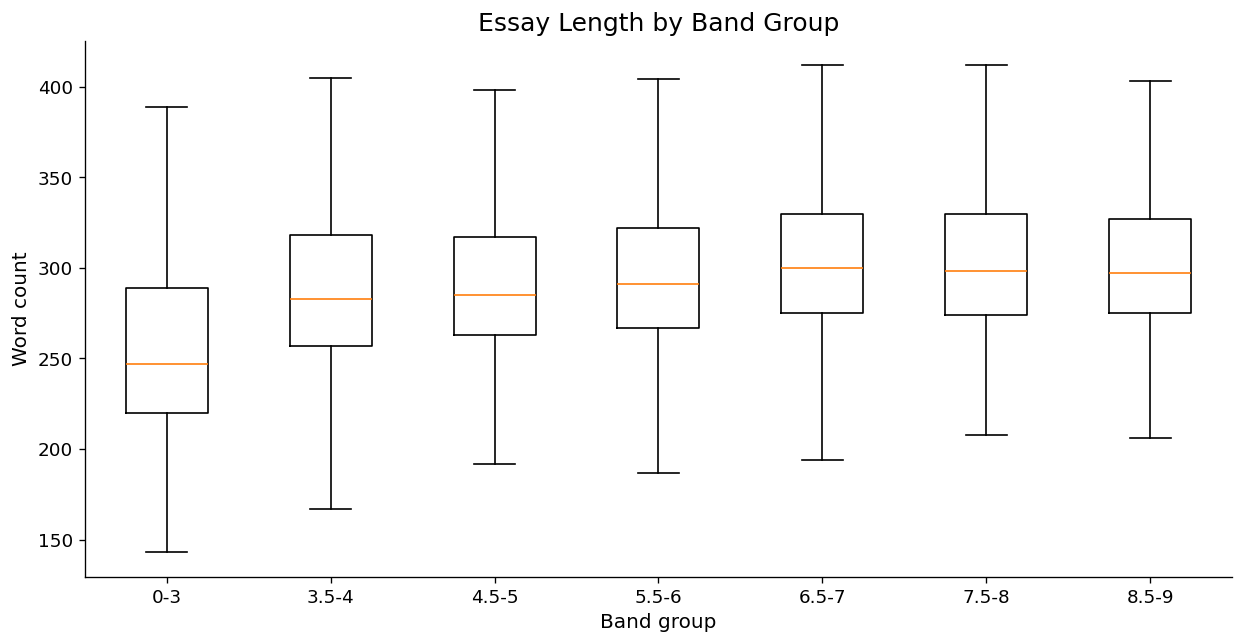

In [14]:
# =========================
# 13. Figure: word count by band group
# Output: figures/eda/word_count_by_band.png
# =========================

plot_df = df_eda.dropna(subset=["band_group", "word_count"]).copy()
groups = [g for g in labels if g in set(plot_df["band_group"].astype(str))]
data = [plot_df.loc[plot_df["band_group"].astype(str) == g, "word_count"].values for g in groups]

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.boxplot(data, labels=groups, showfliers=False)
ax.set_title("Essay Length by Band Group")
ax.set_xlabel("Band group")
ax.set_ylabel("Word count")
clean_ax(ax)
savefig(EDA_DIR / "word_count_by_band.png")

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\eda\feature_trends_by_band.png


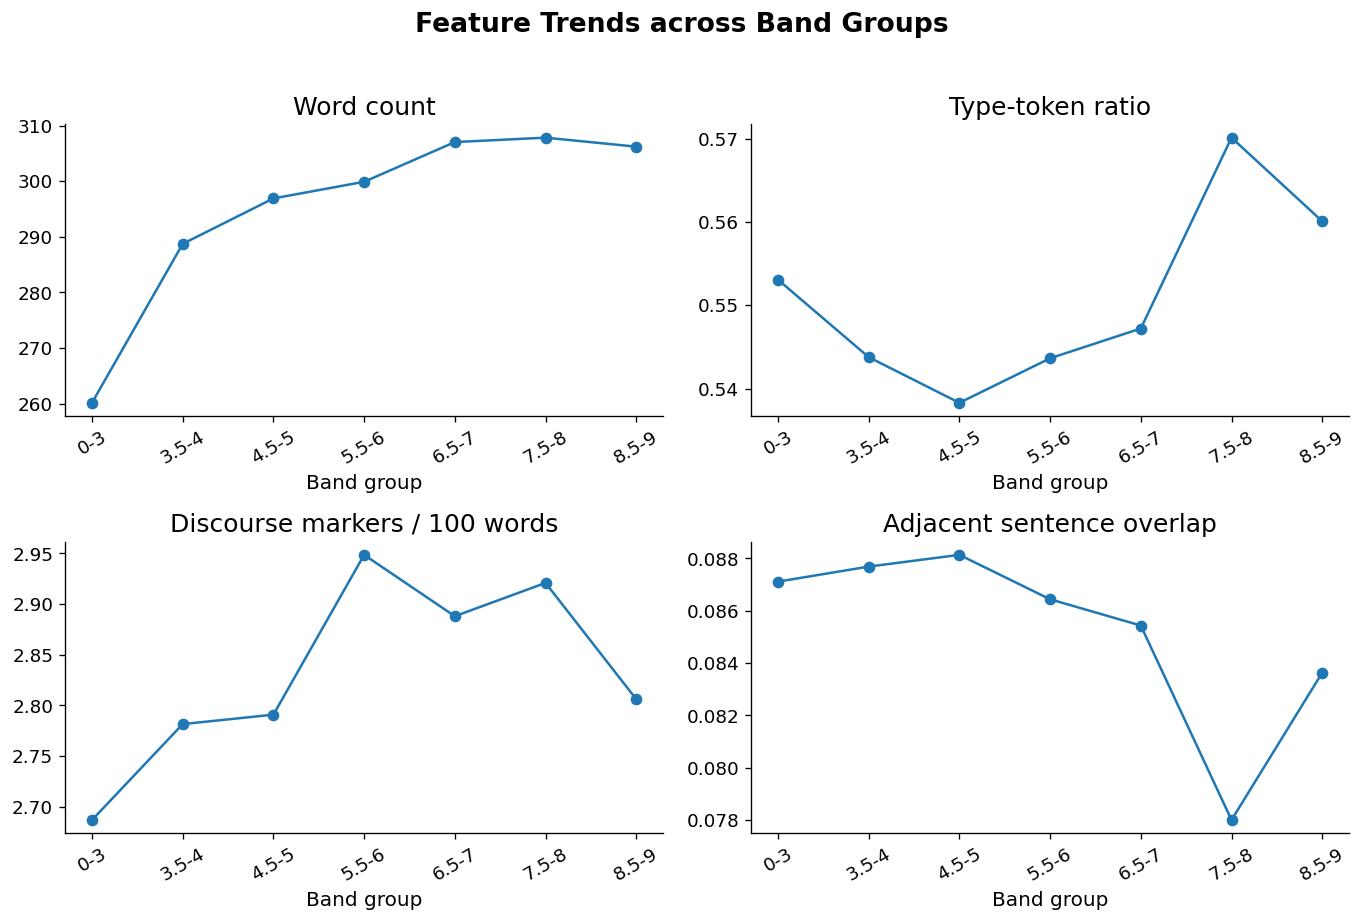

In [15]:
# =========================
# 14. Figure: feature trends by band group
# Output: figures/eda/feature_trends_by_band.png
# =========================

features_to_plot = [
    ("word_count", "Word count"),
    ("type_token_ratio", "Type-token ratio"),
    ("discourse_per_100_words", "Discourse markers / 100 words"),
    ("adjacent_sentence_overlap_mean", "Adjacent sentence overlap")
]

summary = df_eda.groupby("band_group", observed=False)[[f for f, _ in features_to_plot]].mean().reindex(labels)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.5))
axes = axes.ravel()

for ax, (feat, title) in zip(axes, features_to_plot):
    ax.plot(summary.index.astype(str), summary[feat].values, marker="o")
    ax.set_title(title)
    ax.set_xlabel("Band group")
    ax.tick_params(axis="x", rotation=30)
    clean_ax(ax)

plt.suptitle("Feature Trends across Band Groups", fontsize=16, fontweight="bold", y=1.02)
savefig(EDA_DIR / "feature_trends_by_band.png")

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\eda\discourse_feature_boxplots.png


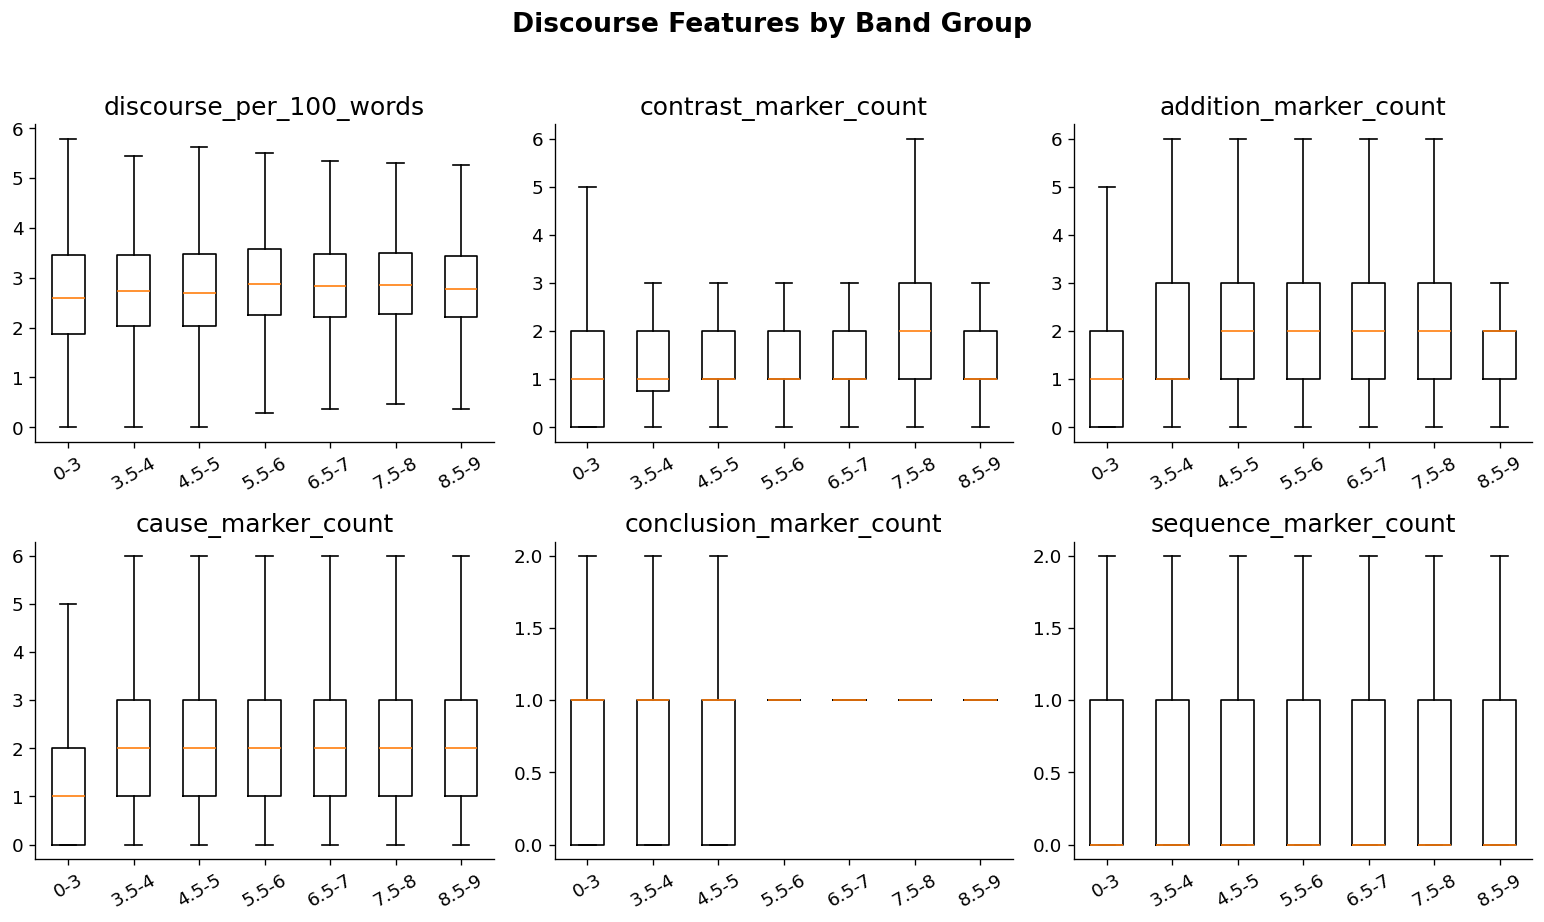

In [16]:
# =========================
# 15. Figure: discourse feature boxplots
# Output: figures/eda/discourse_feature_boxplots.png
# =========================

disc_features = [
    "discourse_per_100_words",
    "contrast_marker_count",
    "addition_marker_count",
    "cause_marker_count",
    "conclusion_marker_count",
    "sequence_marker_count"
]
disc_features = [f for f in disc_features if f in df_eda.columns]

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
axes = axes.ravel()

plot_df = df_eda.dropna(subset=["band_group"]).copy()
groups = [g for g in labels if g in set(plot_df["band_group"].astype(str))]

for ax, feat in zip(axes, disc_features):
    data = [plot_df.loc[plot_df["band_group"].astype(str) == g, feat].values for g in groups]
    ax.boxplot(data, labels=groups, showfliers=False)
    ax.set_title(feat)
    ax.tick_params(axis="x", rotation=30)
    clean_ax(ax)

# Hide unused axes
for j in range(len(disc_features), len(axes)):
    axes[j].axis("off")

plt.suptitle("Discourse Features by Band Group", fontsize=16, fontweight="bold", y=1.02)
savefig(EDA_DIR / "discourse_feature_boxplots.png")

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\pr\pca_feature_space.png


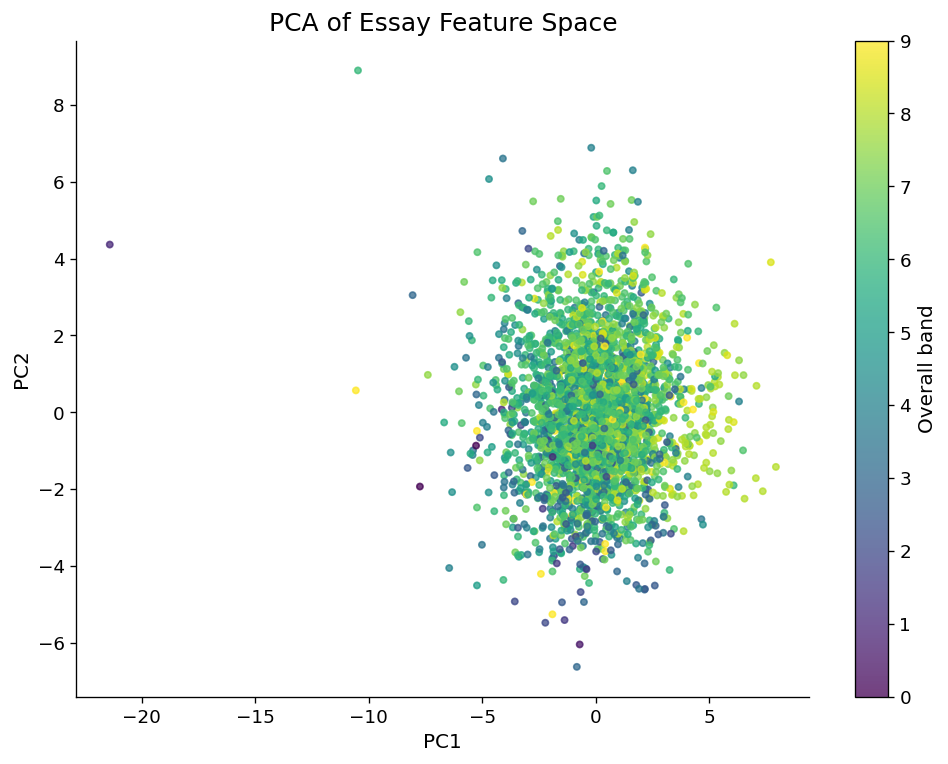

In [17]:
# =========================
# 16. Figure: PCA feature space
# Output: figures/pr/pca_feature_space.png
# =========================

feature_cols = [
    "word_count", "sentence_count", "paragraph_count", "unique_word_count",
    "avg_word_len", "avg_sentence_len", "sentence_len_std", "type_token_ratio",
    "content_word_ratio", "long_word_ratio", "bigram_diversity", "trigram_diversity",
    "prompt_overlap", "adjacent_sentence_overlap_mean", "comma_per_sentence",
    "semicolon_colon_per_sentence", "discourse_marker_count", "discourse_per_100_words",
    "contrast_marker_count", "addition_marker_count", "cause_marker_count",
    "example_marker_count", "conclusion_marker_count", "sequence_marker_count"
]
feature_cols = [c for c in feature_cols if c in df_eda.columns]

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA

    sample_df = df_eda.dropna(subset=feature_cols + ["band"]).copy()
    if len(sample_df) > 3000:
        sample_df = sample_df.sample(3000, random_state=RANDOM_SEED)

    X = sample_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
    X_scaled = StandardScaler().fit_transform(X)
    coords = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=sample_df["band"].values, s=14, alpha=0.75)
    ax.set_title("PCA of Essay Feature Space")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Overall band")
    clean_ax(ax)
    savefig(PR_DIR / "pca_feature_space.png")

except Exception as e:
    print("PCA plot skipped:", e)

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\pr\tsne_feature_space.png


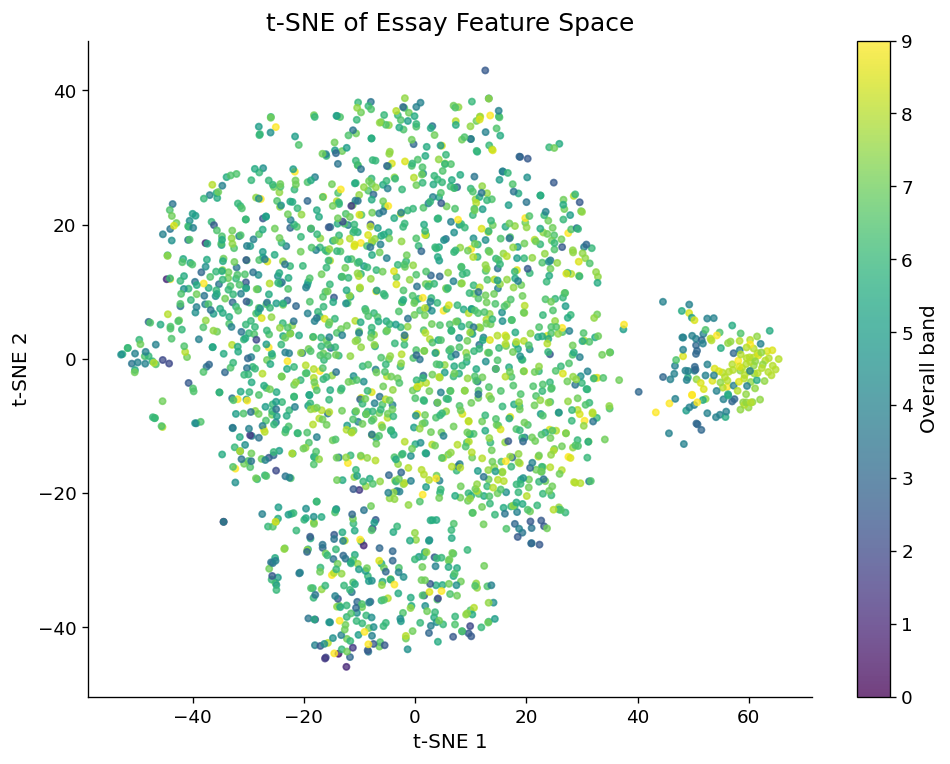

In [18]:
# =========================
# 17. Figure: t-SNE feature space
# Output: figures/pr/tsne_feature_space.png
# =========================

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.manifold import TSNE

    sample_df = df_eda.dropna(subset=feature_cols + ["band"]).copy()
    if len(sample_df) > 2000:
        sample_df = sample_df.sample(2000, random_state=RANDOM_SEED)

    X = sample_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
    X_scaled = StandardScaler().fit_transform(X)

    coords = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_SEED
    ).fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=sample_df["band"].values, s=14, alpha=0.75)
    ax.set_title("t-SNE of Essay Feature Space")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Overall band")
    clean_ax(ax)
    savefig(PR_DIR / "tsne_feature_space.png")

except Exception as e:
    print("t-SNE plot skipped:", e)

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\pr\discourse_feature_space.png


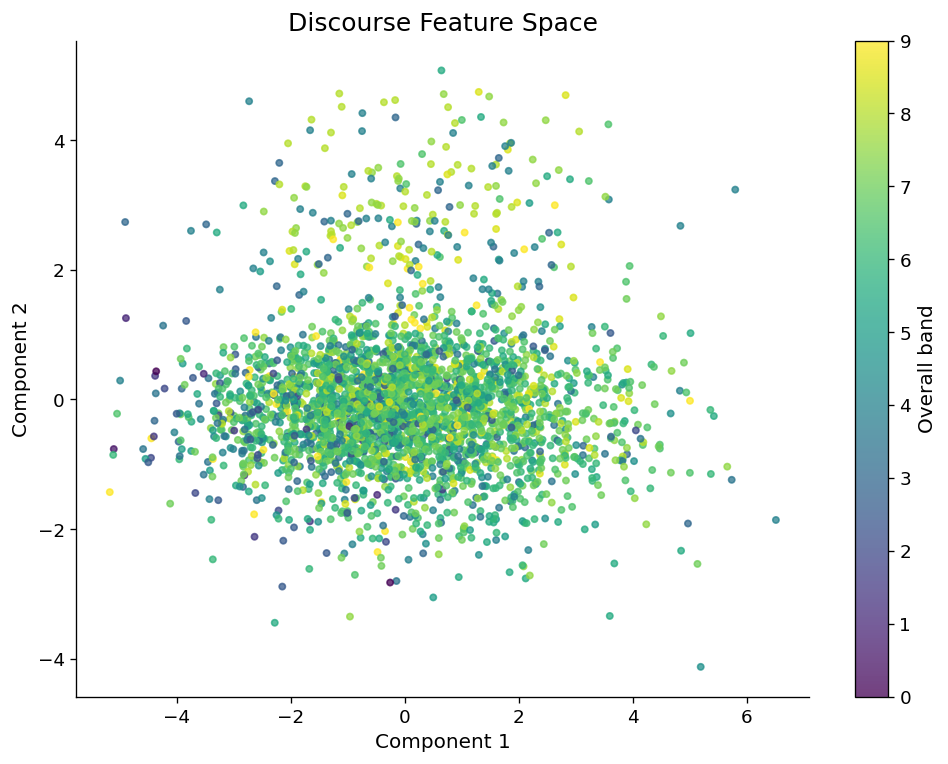

In [19]:
# =========================
# 18. Figure: discourse-only feature space
# Output: figures/pr/discourse_feature_space.png
# =========================

disc_cols = [
    "discourse_marker_count", "discourse_per_100_words",
    "contrast_marker_count", "addition_marker_count", "cause_marker_count",
    "example_marker_count", "conclusion_marker_count", "sequence_marker_count",
    "adjacent_sentence_overlap_mean", "paragraph_count"
]
disc_cols = [c for c in disc_cols if c in df_eda.columns]

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA

    sample_df = df_eda.dropna(subset=disc_cols + ["band"]).copy()
    if len(sample_df) > 3000:
        sample_df = sample_df.sample(3000, random_state=RANDOM_SEED)

    X = sample_df[disc_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
    X_scaled = StandardScaler().fit_transform(X)
    coords = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=sample_df["band"].values, s=14, alpha=0.75)
    ax.set_title("Discourse Feature Space")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Overall band")
    clean_ax(ax)
    savefig(PR_DIR / "discourse_feature_space.png")

except Exception as e:
    print("Discourse feature space plot skipped:", e)

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\results\model_comparison.png


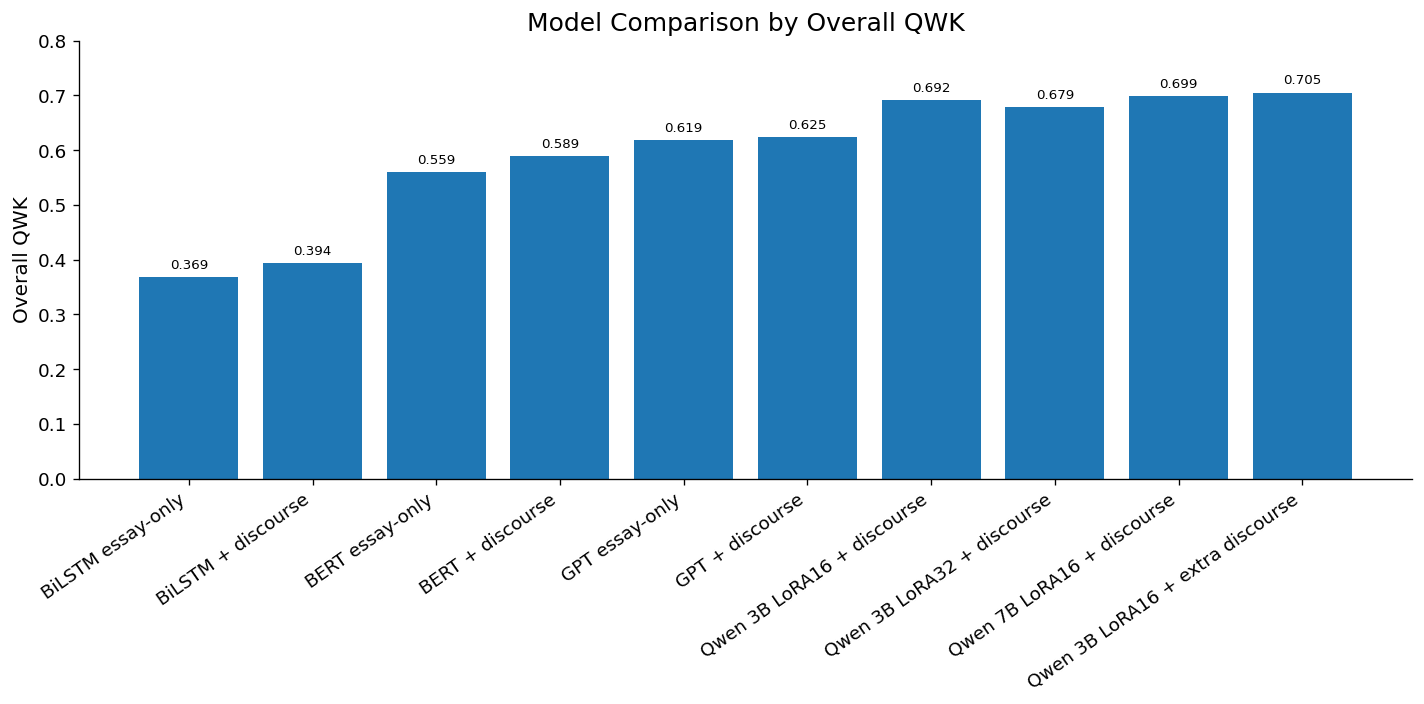

Saved: C:\Users\PC\IELTS-Writing-Evals\slide_figures\results\model_results_table.csv


In [20]:
# =========================
# 19. Figure: model comparison chart for results slide
# Output: figures/results/model_comparison.png
# =========================

# Các giá trị này lấy từ thực nghiệm bạn đã dùng trong slide.
# Có thể sửa lại nếu bạn rerun model và có số mới.
model_results = pd.DataFrame([
    ["BiLSTM essay-only", 0.3671, 1.2802, 0.3690, 1.2799],
    ["BiLSTM + discourse", 0.3948, 1.2357, 0.3940, 1.2387],
    ["BERT essay-only", 0.5544, 1.1835, 0.5592, 1.1680],
    ["BERT + discourse", 0.5818, 1.0254, 0.5892, 1.0041],
    ["GPT essay-only", 0.6158, 0.9595, 0.6189, 0.9407],
    ["GPT + discourse", 0.6184, 0.9570, 0.6246, 0.9340],
    ["Qwen 3B LoRA16 + discourse", 0.6820, 0.8916, 0.6916, 0.8763],
    ["Qwen 3B LoRA32 + discourse", 0.6737, 0.8915, 0.6795, 0.8876],
    ["Qwen 7B LoRA16 + discourse", 0.6937, 0.8567, 0.6987, 0.8495],
    ["Qwen 3B LoRA16 + extra discourse", 0.6996, 0.8820, 0.7052, 0.8649],
], columns=["model", "mean_trait_qwk", "mean_trait_mae", "overall_qwk", "overall_mae"])

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_results))
ax.bar(x, model_results["overall_qwk"].values)
ax.set_xticks(x)
ax.set_xticklabels(model_results["model"], rotation=35, ha="right")
ax.set_ylim(0, 0.8)
ax.set_title("Model Comparison by Overall QWK")
ax.set_ylabel("Overall QWK")
clean_ax(ax)

for i, v in enumerate(model_results["overall_qwk"].values):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

savefig(RESULTS_DIR / "model_comparison.png")
model_results.to_csv(RESULTS_DIR / "model_results_table.csv", index=False)
print("Saved:", RESULTS_DIR / "model_results_table.csv")

In [21]:
# =========================
# 20. Export manifest
# =========================

manifest = {
    "eda": sorted([p.name for p in EDA_DIR.glob("*.png")]),
    "pr": sorted([p.name for p in PR_DIR.glob("*.png")]),
    "results": sorted([p.name for p in RESULTS_DIR.glob("*.png")]),
}

print(json.dumps(manifest, indent=2, ensure_ascii=False))

with open(OUTPUT_ROOT / "figure_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("\nAll figures saved under:", OUTPUT_ROOT)
print("Copy these folders into your Overleaf project as:")
print(" - figures/eda/")
print(" - figures/pr/")
print(" - figures/results/")

{
  "eda": [
    "band_by_split.png",
    "band_distribution.png",
    "dataset_overview_table.png",
    "discourse_feature_boxplots.png",
    "feature_trends_by_band.png",
    "source_split_summary.png",
    "trait_correlation_heatmap.png",
    "trait_distributions_grid.png",
    "word_count_by_band.png"
  ],
  "pr": [
    "discourse_feature_space.png",
    "pca_feature_space.png",
    "tsne_feature_space.png"
  ],
  "results": [
    "model_comparison.png"
  ]
}

All figures saved under: C:\Users\PC\IELTS-Writing-Evals\slide_figures
Copy these folders into your Overleaf project as:
 - figures/eda/
 - figures/pr/
 - figures/results/
